# Lab 6 — Frequency Domain Filtering

**Completed notebook:** frequency-domain Laplacian and Sobel filtering, with executed outputs and observations.


## Setup — Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

%matplotlib inline

---
## Theory — What is Frequency Domain?

Up to now (Labs 5) we filtered by **convolution in the spatial domain** — sliding a kernel over pixels. The **frequency domain** is a different way of thinking about the same image.

### Every image is a sum of waves
The **Fourier Transform** says any image can be written as a sum of sine waves of different frequencies, orientations, and amplitudes.
- **Low frequencies** → slow variations → smooth regions, overall brightness.
- **High frequencies** → fast variations → edges, fine texture, noise.
<img src="https://drive.google.com/uc?export=view&id=15Ys4pawYnCFgLVSqpFi5T1FUll8MHYSv" width="250">
<img src="https://drive.google.com/uc?export=view&id=1NP0vKa22ZuahSmvsPKlN1e1WGavvu71D" width="600">


<img src="https://drive.google.com/uc?export=view&id=15RwTeJMO-IUdSH2e8RXfDi7tkui-UQ_n" width="700">

### Why bother?
Because filtering in the frequency domain is **very intuitive**:
- Want to blur the image? → **kill the high frequencies**.
- Want to sharpen it? → **boost the high frequencies**.
- Want to find edges? → **keep only the high frequencies**.


Mathematically, convolution in space = **multiplication** in frequency:


So instead of convolving a kernel with the image, we:
1. Take the FFT of the image → `F`
2. Multiply by a filter `H`
3. Take the inverse FFT to get the filtered image back

### Key functions in `numpy.fft`

| Function | Purpose |
|---|---|
| `fft2(image)` | 2D Fast Fourier Transform |
| `ifft2(F)` | Inverse 2D FFT (back to image) |
| `fftshift(F)` | Moves zero-frequency to the center (for viewing) |
| `ifftshift(H)` | Moves zero-frequency back to the top-left corner |
| `fftfreq(N)` | Generates frequency values for an N-point FFT |


## Task 1 — Laplacian in the Frequency Domain

In the **spatial domain**, the Laplacian is a 3×3 kernel:

$$\begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

The **continuous Laplacian** has this frequency-domain expression (used in this lab):

$$H(u,v) = -4\pi^2(u^2 + v^2)$$

**Note:** the 3×3 kernel above is a discrete approximation. Its exact discrete frequency response is $2\cos(2\pi u)+2\cos(2\pi v)-4$, which approximates $-4\pi^2(u^2+v^2)$ at low frequencies.


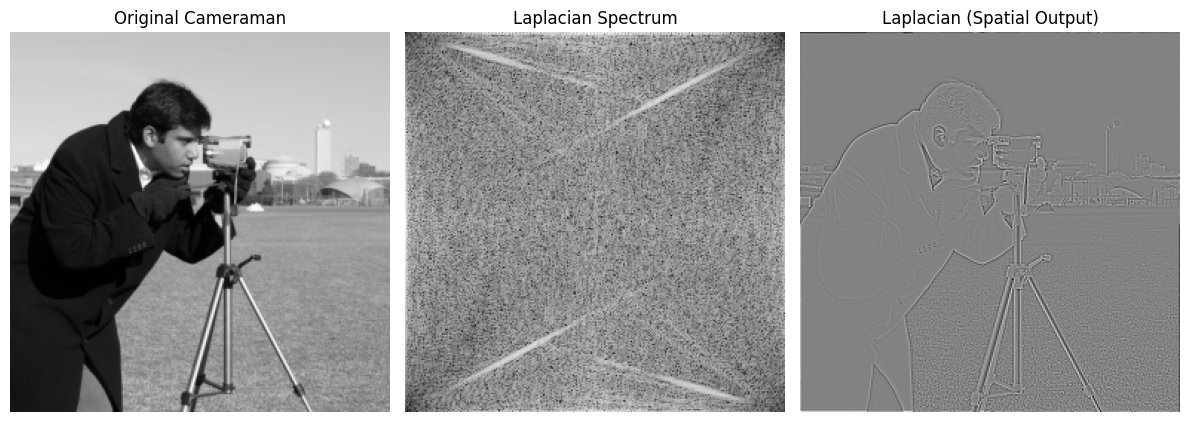

In [2]:
# --- Code from the lab manual ---
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256))   # Resize for faster FFT (optional)

# Get image size
M, N = image.shape

# Generate frequency grid in natural FFT order (zero frequency at [0, 0])
u = np.fft.fftfreq(M).reshape(-1, 1)   # column vector of frequencies for rows
v = np.fft.fftfreq(N).reshape(1, -1)   # row vector of frequencies for columns

# Compute Laplacian filter in frequency domain
laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)

# Apply 2D FFT
F = np.fft.fft2(image)

# Apply Laplacian filter in frequency domain (pointwise multiplication)
F_lap = F * laplacian_filter

# Inverse FFT to get spatial result
laplacian_image = np.fft.ifft2(F_lap).real

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)'); plt.axis('off')

plt.tight_layout(); plt.show()

### Understanding the output
- The **Laplacian spectrum** is displayed without `fftshift`. Zero frequency is at the **top-left**, with low frequencies wrapping around the array boundaries and high frequencies near the middle of each axis. The filter removes the DC component because `laplacian_filter[0, 0] = 0`.
- Bright spectrum values indicate a large filtered magnitude; brightness depends on both the image spectrum and the filter response.
- The **spatial output** is a signed edge response: flat regions are approximately zero, while intensity transitions give positive and negative responses. The grayscale display rescales these values for viewing.


---
## Assessment Task — Sobel Filter in the Frequency Domain

Sobel filters detect edges — one kernel for the x-direction derivative (`sobel_x`, highlighting vertical edges), one for the y-direction derivative (`sobel_y`, highlighting horizontal edges). In the spatial domain these are 3×3 kernels:

$$\text{Sobel}_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix} \quad \text{Sobel}_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$

### Why this task is trickier than Task 1
For the Laplacian, we had a clean closed-form formula `−4π²(u² + v²)` that worked directly on the frequency grid. For Sobel, we only have 3×3 kernels. To use them in the frequency domain, we must:

1. **Pad** each 3×3 kernel to the image's size (e.g., 256×256) by placing it in the **center** of a zero-filled array.
2. Apply `ifftshift` to move the kernel's center from the image center to pixel (0, 0) — the convention FFT expects.
3. FFT the padded kernel to get its frequency response.
4. Multiply with the image's FFT.
5. Inverse FFT to get the result.

The helper function `center_embed_kernel` (provided in the lab) does steps 1–3 for us.

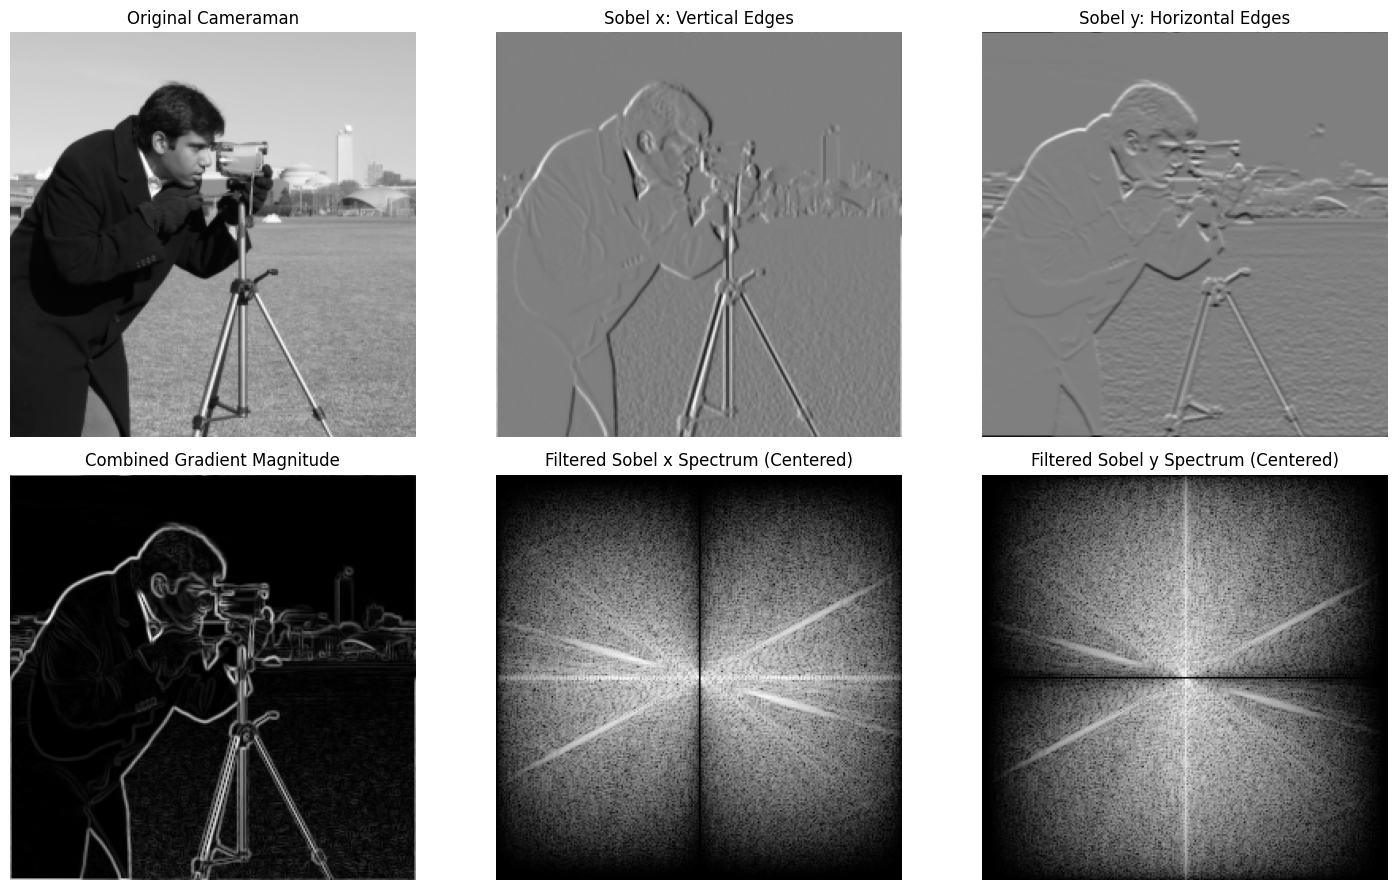

Image and filter shape: (256, 256)
Sobel x range: [-3.179914, 3.302624]
Sobel y range: [-2.978720, 2.664896]
Gradient magnitude range: [0.000110, 3.448091]
Maximum imaginary residual: 8.24e-16


In [3]:
# --- Solution: Sobel filtering in the frequency domain ---
# Reload the image so this task can run independently after the setup cell.
image = resize(data.camera(), (256, 256), anti_aliasing=True)
M, N = image.shape

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=float)
sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=float)


def center_embed_kernel(kernel, shape):
    """Center an odd-sized kernel, move its origin to (0, 0), then FFT."""
    kernel = np.asarray(kernel, dtype=float)
    if kernel.ndim != 2 or len(shape) != 2:
        raise ValueError("Kernel and target shape must be two-dimensional.")
    kh, kw = kernel.shape
    rows, cols = shape
    if kh % 2 == 0 or kw % 2 == 0:
        raise ValueError("Use odd-sized kernels with a well-defined center.")
    if kh > rows or kw > cols:
        raise ValueError("Kernel must fit inside the target image shape.")
    padded = np.zeros(shape, dtype=float)
    # Place the CENTER coefficient at (rows // 2, cols // 2).
    # This also avoids a one-pixel offset for even-sized images.
    r0 = rows // 2 - kh // 2
    c0 = cols // 2 - kw // 2
    padded[r0:r0 + kh, c0:c0 + kw] = kernel
    return fft2(ifftshift(padded))


# Frequency responses in the same (unshifted) order as the image FFT.
H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)
F = fft2(image)
G_x = F * H_x
G_y = F * H_y

# Inverse transforms produce the directional responses.
result_x = ifft2(G_x)
result_y = ifft2(G_y)
gx = result_x.real
gy = result_y.real
# Combine both directions to show edges of any orientation.
gradient_magnitude = np.hypot(gx, gy)

# Use a shared symmetric scale to compare the signed directional responses.
limit = max(np.max(np.abs(gx)), np.max(np.abs(gy)))
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0, 0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Original Cameraman')
axes[0, 1].imshow(gx, cmap='gray', vmin=-limit, vmax=limit)
axes[0, 1].set_title('Sobel x: Vertical Edges')
axes[0, 2].imshow(gy, cmap='gray', vmin=-limit, vmax=limit)
axes[0, 2].set_title('Sobel y: Horizontal Edges')
axes[1, 0].imshow(gradient_magnitude, cmap='gray', vmin=0)
axes[1, 0].set_title('Combined Gradient Magnitude')
axes[1, 1].imshow(np.log1p(np.abs(fftshift(G_x))), cmap='gray')
axes[1, 1].set_title('Filtered Sobel x Spectrum (Centered)')
axes[1, 2].imshow(np.log1p(np.abs(fftshift(G_y))), cmap='gray')
axes[1, 2].set_title('Filtered Sobel y Spectrum (Centered)')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image and filter shape: {image.shape}")
print(f"Sobel x range: [{gx.min():.6f}, {gx.max():.6f}]")
print(f"Sobel y range: [{gy.min():.6f}, {gy.max():.6f}]")
print(f"Gradient magnitude range: [{gradient_magnitude.min():.6f}, "
      f"{gradient_magnitude.max():.6f}]")
print(f"Maximum imaginary residual: "
      f"{max(np.abs(result_x.imag).max(), np.abs(result_y.imag).max()):.2e}")


### Assessment — Observations and interpretation

- **`sobel_x`** measures changes across columns, so vertical boundaries stand out. **`sobel_y`** measures changes across rows, so horizontal boundaries stand out.
- The combined edge strength is $\sqrt{g_x^2 + g_y^2}$. It is nonnegative and includes edges in both directions.
- Both kernels sum to zero, so their DC response is zero: uniform brightness does not produce an edge response.
- Padding gives the kernel FFT the same shape as the image FFT. `ifftshift` puts the kernel's center at the FFT origin, avoiding a displaced output.
- `fftshift` is used only in the spectrum plots. The multiplication uses matching, unshifted FFT arrays.
- Taking `.real` removes negligible floating-point imaginary residuals. It does not mean taking the absolute value of the signed derivative.
- Same-size FFT multiplication performs **circular convolution**: opposite image boundaries wrap around, which can create border edges. Zero-padding to at least $(M+2, N+2)$ before filtering, followed by appropriate cropping, would instead support linear convolution for a 3×3 kernel.
- These results use **convolution**. Software that applies Sobel kernels by correlation can return the opposite sign for each directional response; the combined magnitude remains the same.


---
## Summary Table

| Filter | What it does | How it's built in frequency domain |
|---|---|---|
| **Laplacian** (high-pass) | Edge detection, sharpening | `H = −4π²(u² + v²)` |
| **Sobel** (high-pass) | Directional edge detection | Pad 3×3 kernel, `ifftshift`, FFT |
| **Ideal Low-Pass** | Hard blur (causes ringing) | `H = 1 if D ≤ D0 else 0` |
| **Gaussian Low-Pass** | Smooth blur (no ringing) | `H = exp(−D² / 2D0²)` |
| **Gaussian High-Pass** | Edge enhancement | `H = 1 − Gaussian LP` |

## The general recipe for any frequency-domain filter

```python
# 1. Load image
image = data.camera()

# 2. Compute FFT
F = fft2(image)

# 3. Design filter H in frequency space (same shape as image)
H = ...  # Laplacian, Gaussian LP, Sobel, etc.

# 4. Multiply (not convolve!)
G = F * H

# 5. Inverse FFT to get filtered image
filtered = np.real(ifft2(G))
```

**Remember:**
- Keep FFTs in their natural un-shifted order for **computation**.
- Only `fftshift` for **display**, then `ifftshift` before filtering if needed.
- Ignore the imaginary part with `.real` or `np.real()` after `ifft2` — it should be numerically near zero for real-valued filters.

**End of notebook.**